# 02 — Comparative Analysis: Albania vs. Peer Countries (PISA 2022)

Cross-country comparison across Balkan peers (MKD, MNE, SRB, BGR), top performers (EST, FIN), and GDP-matched economies (MEX, COL). Dataset: 323,121 students, 9 countries, 5 cycles.

In [1]:
import sys, os
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # project root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)

In [2]:
from src.features.target import add_all_targets
df = add_all_targets(pd.read_parquet('../data/processed/comparison_dataset.parquet'))
print('Rows:', len(df))
df.pivot_table(index='COUNTRY', columns='CYCLE', values='MATH_PV_MEAN', aggfunc='count', fill_value=0).astype(int)

2026-07-01 14:50:09 [info     ] Point target added             at_risk_rate=0.47 domain=math threshold=420.07


2026-07-01 14:50:11 [info     ] Point target added             at_risk_rate=0.381 domain=reading threshold=407.47


2026-07-01 14:50:16 [info     ] Point target added             at_risk_rate=0.399 domain=science threshold=409.54


Rows: 323121


CYCLE,2009,2012,2015,2018,2022
COUNTRY,,,,,
ALB,4596,4743,5215,6359,6129
BGR,4507,5282,5928,5294,6107
COL,7921,9073,11795,7522,7804
EST,4727,4779,5587,5316,6392
FIN,5810,8829,5882,5649,10239
MEX,38250,33806,7568,7299,6288
MKD,0,0,5324,5569,6610
MNE,4825,4744,5665,6666,5793
SRB,5523,4684,0,6609,6413


## 1. Low-proficiency ranking (2022)

Where does Albania stand against peers?

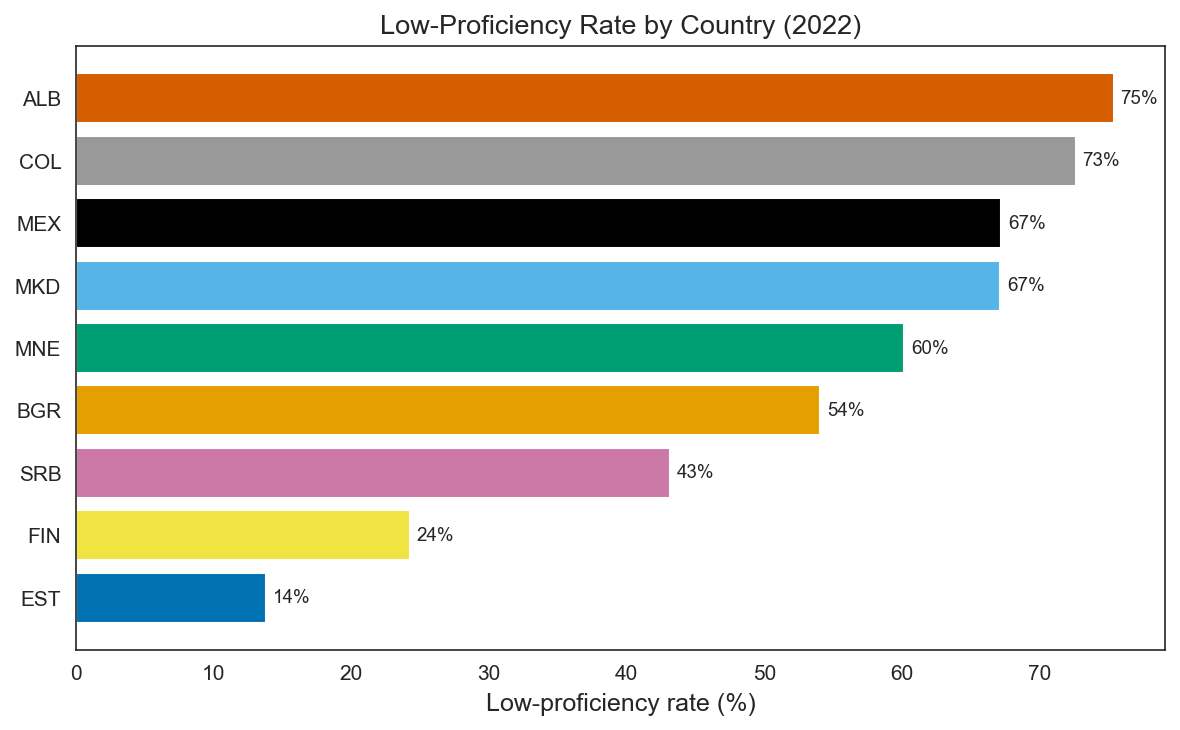

In [3]:
from src.visualization.eda import plot_country_atrisk_ranking
fig = plot_country_atrisk_ranking(df, cycle=2022); plt.show()

**Reading:** Albania has the highest low-proficiency rate (~75%) — above its Balkan neighbours and GDP-matched peers, and ~5× Estonia's rate. This motivates studying *which factors* differ.

## 1b. Ranking with design-based standard errors (BRR + PVs)

The bar chart ranks point estimates; to judge whether two countries *differ significantly* we need proper PISA standard errors. `pv_statistic_brr` combines BRR sampling variance (80 Fay replicate weights, per PV) with the between-plausible-value (Rubin) variance. All nine 2022 cohorts have replicate weights, so every SE here is fully design-based.

In [4]:
from src.data.weights import pv_statistic_brr
d22 = df[df.CYCLE==2022]
rows = []
for cnt in sorted(d22.COUNTRY.unique()):
    r = pv_statistic_brr(d22[d22.COUNTRY==cnt], statistic='at_risk', domain='math')
    rows.append({'country':cnt,
                 'at_risk':round(r['estimate'],4),
                 'SE':round(r['se'],4),
                 'ci95_low':round(r['ci95_low'],4),
                 'ci95_high':round(r['ci95_high'],4),
                 'FMI':round(r['fmi'],3)})
pd.DataFrame(rows).sort_values('at_risk', ascending=False).reset_index(drop=True)

,country,at_risk,SE,ci95_low,ci95_high,FMI
0,ALB,0.7394,0.0041,0.7314,0.7474,0.354
1,COL,0.7122,0.0066,0.6993,0.7251,0.356
2,MKD,0.6624,0.0040,0.6546,0.6702,0.796
3,MEX,0.6581,0.0055,0.6473,0.6690,0.329
4,MNE,0.5950,0.0043,0.5865,0.6036,0.671
5,BGR,0.5360,0.0064,0.5235,0.5485,0.375
6,SRB,0.4307,0.0052,0.4206,0.4408,0.339
7,FIN,0.2486,0.0035,0.2418,0.2554,0.446
8,EST,0.1497,0.0033,0.1432,0.1561,0.497


**Reading:** Albania's CI sits clearly above the Balkan peers' — the gap is not sampling noise. Estonia's non-overlapping low CI confirms the extremes are statistically distinct.

## 2. SES gradient by country (2022)

Slope of math score on ESCS. A steeper slope = stronger socioeconomic determinism. Estonia's flatter slope shows it partly breaks the SES–achievement link.

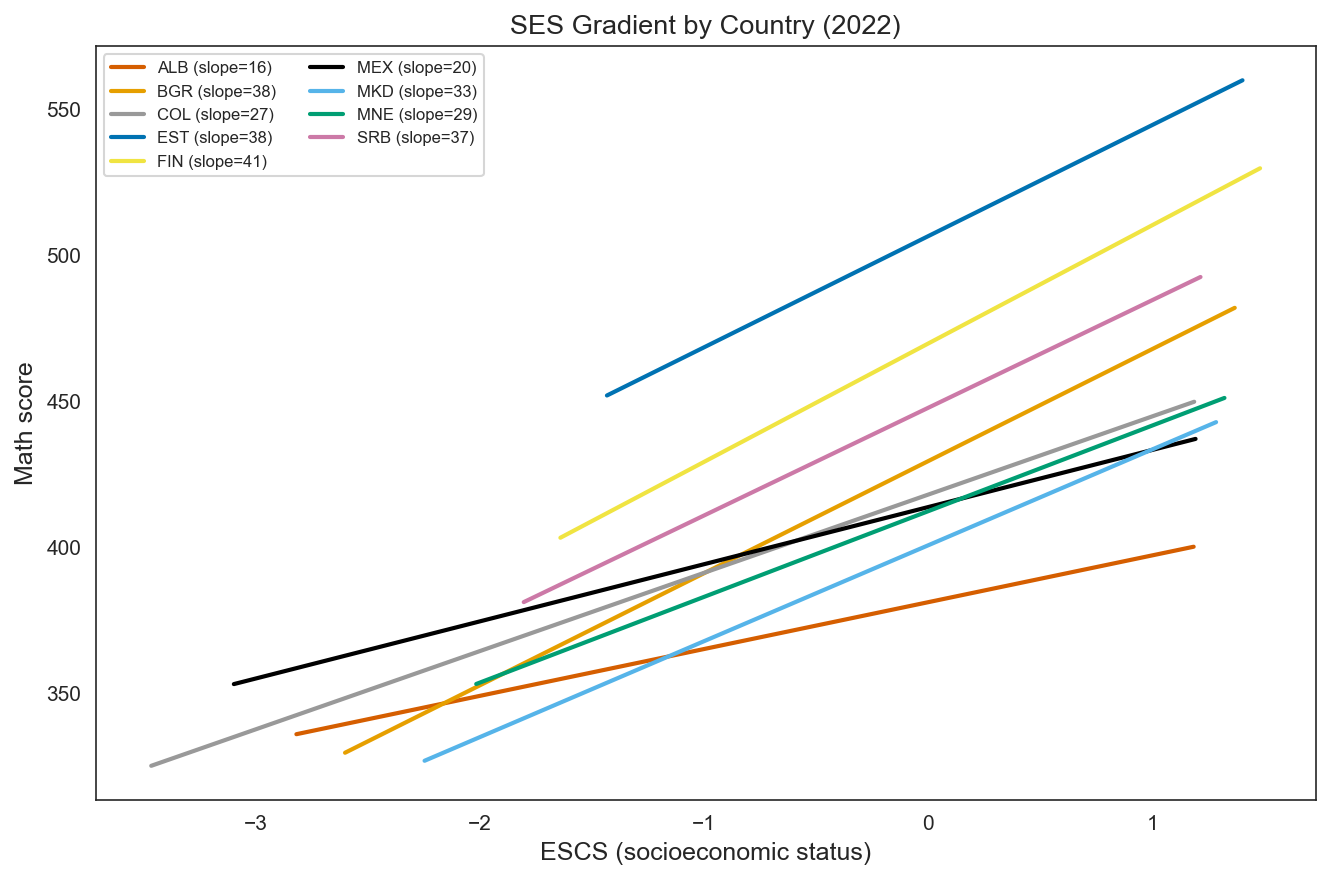

In [5]:
from src.visualization.eda import plot_ses_gradient_by_country
fig = plot_ses_gradient_by_country(df, cycle=2022); plt.show()

## 3. Longitudinal trajectories — all countries

Weighted low-proficiency rate over time, per country.

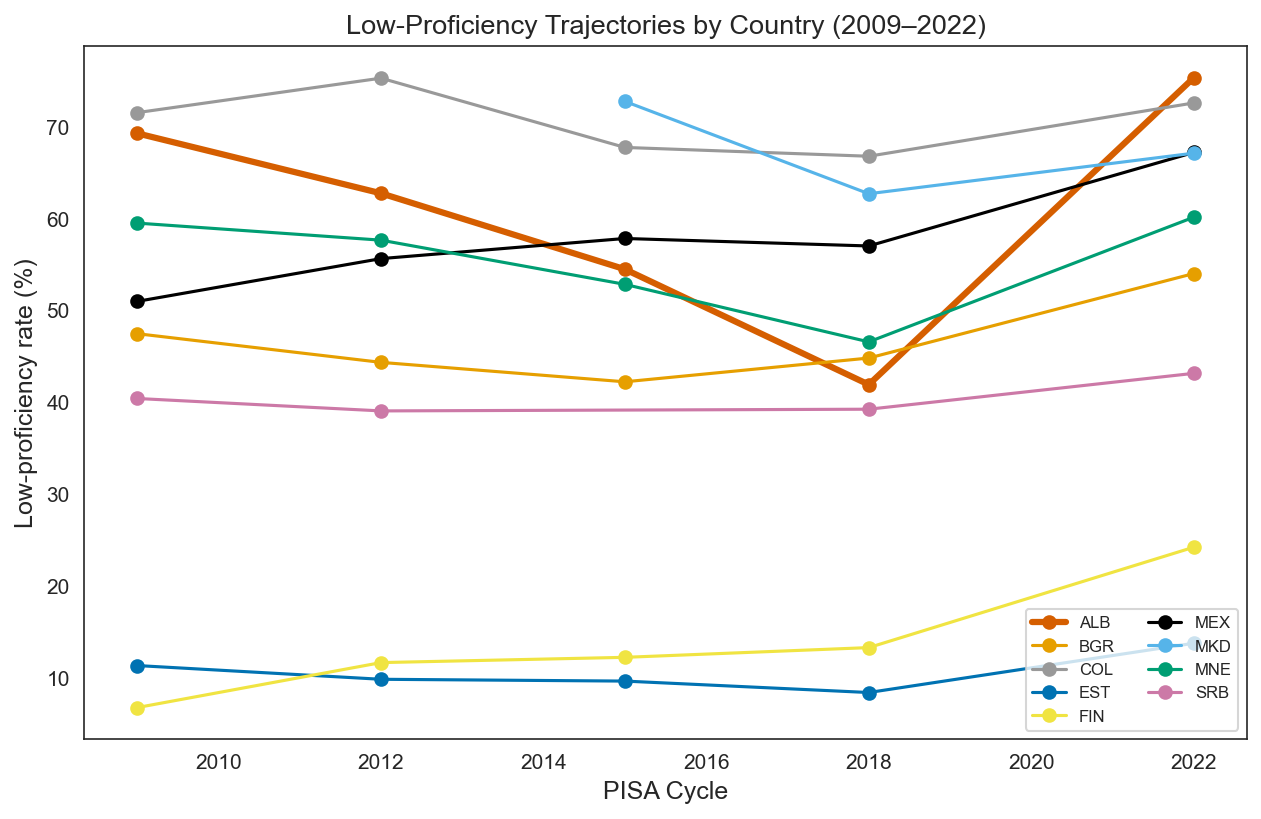

In [6]:
from src.data.weights import weighted_proportion
from src.visualization.style import apply_publication_style, COUNTRY_COLORS
apply_publication_style()
fig, ax = plt.subplots(figsize=(10,6))
for cnt in sorted(df.COUNTRY.unique()):
    sub = df[df.COUNTRY==cnt]
    pts = []
    for c in sorted(sub.CYCLE.unique()):
        s = sub[sub.CYCLE==c]
        if len(s) < 100: continue
        pts.append((c, weighted_proportion(s['AT_RISK_MATH'], s['W_FSTUWT'])*100))
    if pts:
        xs, ys = zip(*pts)
        lw = 3 if cnt=='ALB' else 1.5
        ax.plot(xs, ys, marker='o', label=cnt, color=COUNTRY_COLORS.get(cnt,'#888'), linewidth=lw)
ax.set_xlabel('PISA Cycle'); ax.set_ylabel('Low-proficiency rate (%)')
ax.set_title('Low-Proficiency Trajectories by Country (2009–2022)')
ax.legend(ncol=2, fontsize=8); plt.show()

**Takeaway:** Albania's 2022 spike is unusually sharp relative to peers, several of which also regressed post-COVID but less severely.

## Conclusions & Interpretation

- **Albania is the negative outlier.** 2022 low-proficiency ≈ **75%** — highest in the panel, above Balkan peers (N. Macedonia 67%, Montenegro 60%) and GDP-matched economies (Colombia 73%, Mexico 67%), and ~5× Estonia (**14%**).
- **Steeper SES gradient.** Albania's math-on-ESCS slope is among the steepest; Estonia's is flat — high performance with weak socioeconomic determinism, the opposite policy profile.
- **Shared but uneven regression.** Several peers dipped in 2022, none as sharply as Albania — its spike is structurally distinct, not a common regional shock.
- **Next:** is Albania's shift merely lower scores, or a change in *who* is at risk? → notebook 03.